<a href="https://colab.research.google.com/github/MarianaChiorboli/ciencia_de_dados_arvore_decis-o/blob/main/decision_tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
from sklearn.datasets import load_iris
from sklearn import tree
import graphviz
from sklearn.model_selection import cross_val_score
from sklearn.inspection import permutation_importance
import dtreeviz.trees
import pandas as pd
from sklearn import datasets
from matplotlib import pyplot as plt
import numpy as np

In [29]:
dataset = pd.read_csv("macksound_dataset_12k.csv")

In [30]:
dataset.head()

,id_usuario,id_musica,timestamp_execucao,hora_do_dia,dia_da_semana,genero_musical,artista,popularidade_faixa,modo,duracao_ms,danceability,energy,valence,tempo,loudness,tempo_executado_s,taxa_conclusao,curtiu,skip_30s
0,USR_472,TRK_2387,2026-01-01 00:00:00,0,Thursday,Sertanejo,Artista_047,Média,Menor,207071,208.0,671.00,0.9,77.16,-12.52,79.90,3.859,1,0
1,USR_250,TRK_4041,2026-01-01 00:02:00,0,Thursday,Hip-Hop,Artista_161,Baixa,Menor,247410,777.0,431.00,803.0,171.26,-4.12,159.55,6.449,1,0
2,USR_035,TRK_5426,2026-01-01 00:04:00,0,Thursday,Funk,Artista_116,Média,Maior,170209,662.0,0.96,432.0,176.85,-15.69,57.25,3.364,0,0
3,USR_223,TRK_7592,2026-01-01 00:06:00,0,Thursday,Hip-Hop,Artista_044,Média,Menor,206769,134.0,501.00,571.0,165.27,-17.84,144.64,6.995,0,0
4,USR_044,TRK_5633,2026-01-01 00:08:00,0,Thursday,Pop,Artista_015,Baixa,Maior,226528,518.0,0.62,618.0,113.69,-3.21,47.55,2.099,1,0


In [31]:
dataset.shape

(12050, 19)

In [32]:
colunas_categoricas = ['dia_da_semana', 'genero_musical', 'popularidade_faixa', 'modo']
colunas_numericas = ['hora_do_dia', 'duracao_ms', 'danceability', 'energy', 'valence', 'tempo', 'loudness']
X = dataset[colunas_categoricas + colunas_numericas]
print(X)

      dia_da_semana genero_musical popularidade_faixa   modo  hora_do_dia  \
0          Thursday      Sertanejo              Média  Menor            0   
1          Thursday        Hip-Hop              Baixa  Menor            0   
2          Thursday           Funk              Média  Maior            0   
3          Thursday        Hip-Hop              Média  Menor            0   
4          Thursday            Pop              Baixa  Maior            0   
...             ...            ...                ...    ...          ...   
12045        Friday        Hip-Hop              Média  Maior            4   
12046      Thursday            MPB              Média  Maior            1   
12047      Saturday          Indie              Média  Menor            9   
12048       Tuesday           Rock              Média  Menor            6   
12049        Friday           Funk              Média  Maior           16   

       duracao_ms  danceability  energy  valence   tempo  loudness  
0     

In [33]:
y = dataset['skip_30s']
print(y)

0        0
1        0
2        0
3        0
4        0
        ..
12045    0
12046    0
12047    0
12048    0
12049    1
Name: skip_30s, Length: 12050, dtype: int64


In [34]:
clf = tree.DecisionTreeClassifier(criterion='entropy')
one_hot_data = pd.get_dummies(X, columns=colunas_categoricas, drop_first=True)
clf = clf.fit(one_hot_data, y)

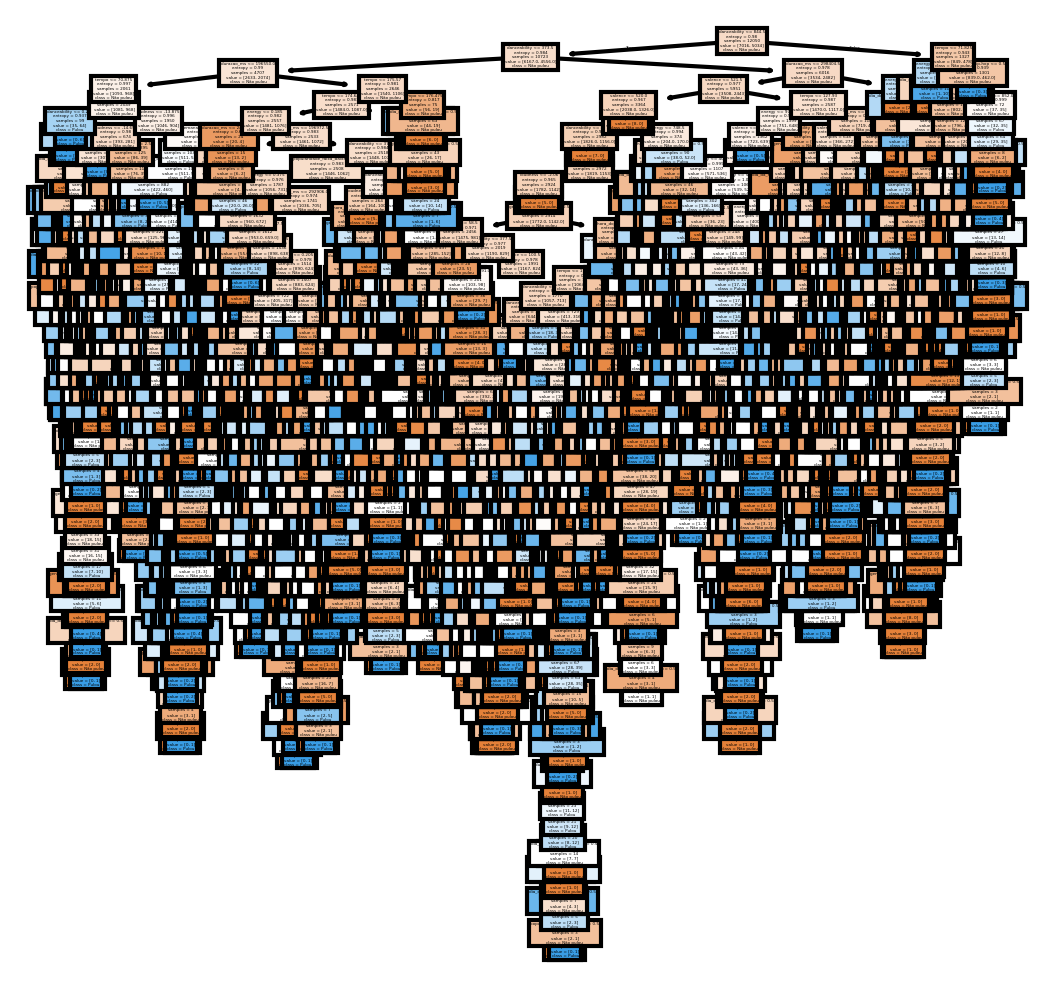

In [35]:
fn = one_hot_data.columns.tolist()
cn = ['Não pulou', 'Pulou']
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(4,4), dpi=300)
tree.plot_tree(clf,
               feature_names=fn,
               class_names=cn,
               filled=True);
fig.savefig('imagename.png')

Text(0.5, 1.0, 'Feature Importance')

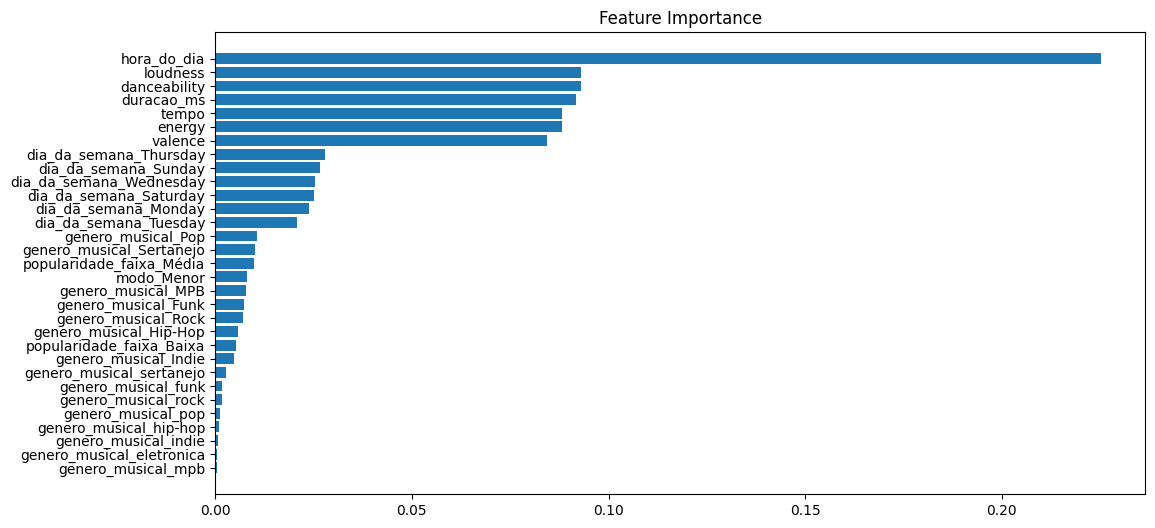

In [36]:
feature_importance = clf.feature_importances_
sorted_idx = np.argsort(feature_importance)
fig = plt.figure(figsize=(12, 6))
plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx], align='center')
plt.yticks(range(len(sorted_idx)), np.array(fn)[sorted_idx])
plt.title('Feature Importance')

Referências

https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html

https://www.rasgoml.com/feature-engineering-tutorials/how-to-generate-feature-importance-plots-from-scikit-learn

https://medium.com/chinmaygaikwad/feature-importance-and-visualization-of-tree-models-d491e8198b0a

